# Data Analysis of the MIT-LI-ion Battery Dataset

Rough overview of the raw dataset, before/after cleaning, and the engineered feature/label table produced by `loader.py` and `features.py`.

Source: Kaggle "Lithium-Ion Battery Cycle Life Time Series Dataset". It has 140 batteries with fast-charging protocols, cycled to end of life.

## 1. Setup

In [3]:
import sys
sys.path.append('../V2/source')
import pandas as pd
import matplotlib.pyplot as plt

from loader import load_raw, clean_data
from features import build_feature_table, add_labels

pd.set_option('display.max_columns', 15)
pd.set_option('display.width', 130)


## 2. Raw data -- shape and structure

In [5]:
raw = load_raw('../data/raw/Lithium-Ion Battery Cycle Life.csv')
print(raw.shape)
raw.head(3)

(114738, 13)


,IR,QC,QD,Tavg,Tmin,Tmax,chargetime,cycle,battery_id,cycle_life,C1,Q1,C2
0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.0,b1c0,1190.0,3.6,80.0,3.6
1,0.016742,1.071042,1.070689,31.875011,29.566130,35.652016,13.341250,2.0,b1c0,1190.0,3.6,80.0,3.6
2,0.016724,1.071674,1.071900,31.931490,29.604385,35.692978,13.425777,3.0,b1c0,1190.0,3.6,80.0,3.6


Notice row 0 (cycle 1): every reading is exactly `0.0`. This is a real sensor handshake artifact present across nearly all batteries -`clean_data()` drops cycle 1 for this reason so as to prevent data leakage

In [6]:
cleaned = clean_data(raw)
print(cleaned.shape, '|', cleaned.battery_id.nunique(), 'batteries')
cleaned.groupby('battery_id').size().describe()

(114598, 13) | 140 batteries


count     140.000000
mean      818.557143
std       354.082608
min       169.000000
25%       529.750000
50%       786.000000
75%      1001.750000
max      2236.000000
dtype: float64

## 3. Capacity fade curves -- the core degradation signal

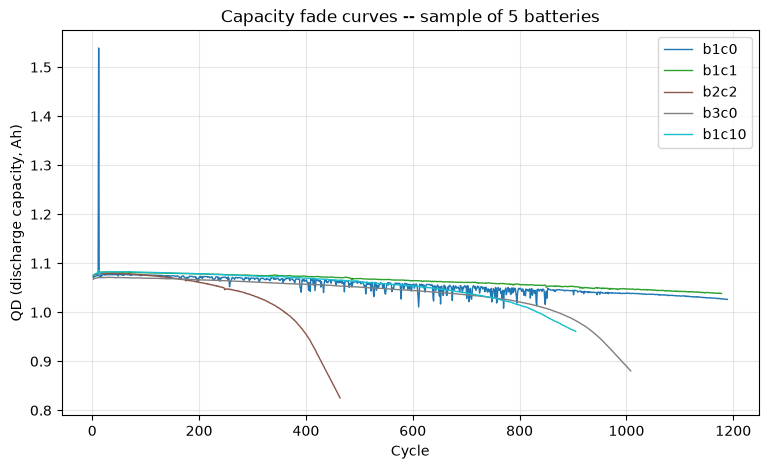

In [7]:
import numpy as np
sample_ids = ['b1c0','b1c1','b2c2','b3c0','b1c10']
fig, ax = plt.subplots(figsize=(9,5))
colors = plt.cm.tab10(np.linspace(0,1,len(sample_ids)))
for bid, c in zip(sample_ids, colors):
    b = cleaned[cleaned.battery_id==bid].sort_values('cycle')
    ax.plot(b.cycle, b.QD, label=bid, color=c, linewidth=1)
ax.set_xlabel('Cycle'); ax.set_ylabel('QD (discharge capacity, Ah)')
ax.set_title('Capacity fade curves -- sample of 5 batteries')
ax.legend(); ax.grid(alpha=0.3)
plt.show()

Very different fade rates and lifetimes across batteries as this dataset spans multiple fast-charging protocols, which is exactly why features are ratio-normalized against each battery's own baseline rather than compared on absolute scale.

## 4. Cycle-life distribution across the fleet

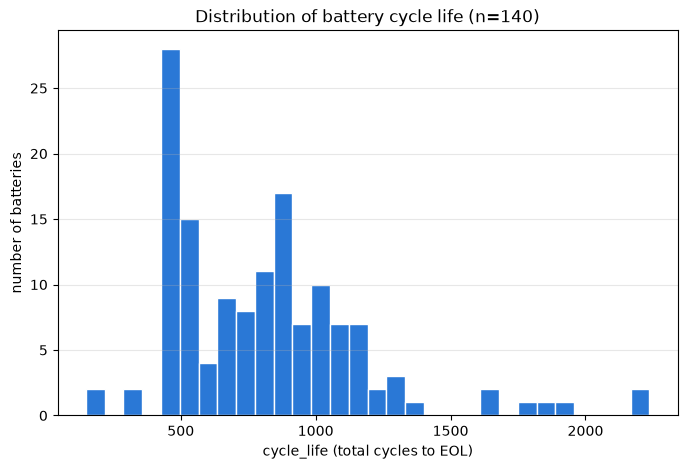

count     140.000000
mean      811.814286
std       361.979303
min       148.000000
25%       501.250000
50%       788.000000
75%      1003.750000
max      2237.000000
Name: cycle_life, dtype: float64

In [8]:
life = cleaned.groupby('battery_id')['cycle_life'].first()
fig, ax = plt.subplots(figsize=(8,5))
ax.hist(life, bins=30, color='#2a78d6', edgecolor='white')
ax.set_xlabel('cycle_life (total cycles to EOL)'); ax.set_ylabel('number of batteries')
ax.set_title('Distribution of battery cycle life (n=140)')
ax.grid(alpha=0.3, axis='y')
plt.show()
life.describe()

Huge spread as some batteries fail in ~150 cycles, others last 2,200+. This is a normal phenomena and not noise unlike faulty value cases. RUL is defined directly from each battery's own `cycle_life` (`rul_cycles = cycle_life - cycle`), so this spread is exactly what the RUL regressor has to learn to predict from behavioral signals alone.

## 5. Engineered features + labels

In [9]:
feats = add_labels(build_feature_table(cleaned))
print(feats.shape)
feats.columns.tolist()

(114598, 21)


['IR',
 'QC',
 'QD',
 'Tavg',
 'Tmin',
 'Tmax',
 'chargetime',
 'cycle',
 'battery_id',
 'cycle_life',
 'C1',
 'Q1',
 'C2',
 'is_capacity_anomaly',
 'capacity_rated',
 'IR_ratio',
 'chargetime_ratio',
 'is_ratio_anomaly',
 'soh',
 'rul_cycles',
 'needs_replacement']

## 6. Data quality- flags working as designed

In [10]:
print('RAW (unfiltered) soh max:', feats.soh.max())

clean_view = feats[(~feats.is_capacity_anomaly) & (~feats.is_ratio_anomaly)]
print('CLEAN (filtered)  soh max:', clean_view.soh.max())
print()
print(f'Flagged is_capacity_anomaly: {feats.is_capacity_anomaly.sum()} rows')
print(f'Flagged is_ratio_anomaly:    {feats.is_ratio_anomaly.sum()} rows')
print(f'Total: {len(feats)} | Clean usable: {len(clean_view)}')

RAW (unfiltered) soh max: 2.6995100869705375
CLEAN (filtered)  soh max: 1.0065354171610572

Flagged is_capacity_anomaly: 2951 rows
Flagged is_ratio_anomaly:    14 rows
Total: 114598 | Clean usable: 111640


**Why the raw max is 2.70:** a handful of individual cycles have corrupted `QD` readings (e.g. one isolated spike in `b1c0`as we can see from above graph). These are real sensor glitches, not real capacity jumps. The MAD-based outlier check in `features.py` correctly catches these and so `capacity_rated` never gets contaminated by them, and downstream model training excludes them entirely. The raw table intentionally keeps the flagged rows' original (weird-looking) values visible rather than silently clipping them. Instead the flag is the mechanism that protects training.

## 7. Label distributions

In [11]:
clean_view[['soh','rul_cycles','needs_replacement']].describe()

,soh,rul_cycles,needs_replacement
count,111640.000000,111640.000000,111640.000000
mean,0.962480,475.489663,0.006736
std,0.045511,372.181835,0.081796
min,0.760990,0.000000,0.000000
25%,0.949235,193.000000,0.000000
50%,0.979459,401.000000,0.000000
75%,0.994684,676.000000,0.000000
max,1.006535,2235.000000,1.000000


**Key things worth rememberingg**:
- `needs_replacement` is severely imbalanced (~0.67% positive)- This is a skewed dataset and hence F1 is a much more important metric.Especially recall as we would rather want the model to have false positives than yield false negatives which means higher recall than precision,
- `soh` correctly bounded [0,1] only in the clean view. We need to always check our 2 anomaly flags before using that data in training our models.
- Battery-level heterogeneity is large. GroupKFold (grouped by `battery_id`) is very very crucial as a random 80/20 split would make it such that the same battery might appear in both test and training of the models. Instead we leave some entire batteries out to make our models a tad bit more accurate at the least to generalise to variance or new data(same thing)

## 8. Summary

- 140 batteries, 114,598 raw cycles. This is a huge diversity in fast-charging protocol and resulting cycle life which varies a lot (148 to 2,237 cycles). This gives us a varying dataset that can help us train a much more accurate and practical model
- Two independent data-quality issues found and handled: isolated `QD` sensor glitches (MAD-based flag, 2,951 rows) and rare extreme `chargetime`/`IR` ratio spikes (14 rows). Both excluded from training to keep the data as clean and reliable as possible
- Labels (`soh`, `rul_cycles`, `needs_replacement`) computed directly and transparently. No leakage and no indirect formulae to derive them unlike V1 which is extremely inaccurate with variance due to RUL=15000-Cycle Last. This is because V1 faced an issue where we replaced the blown up RUL predictions by a upper cap of 15000 assuming every battery eventually ends at 15k cycles.